# CNNs para Clasificación de Imágenes
## Deep Learning con Convolutional Neural Networks (CNNs)
Objetivos del Notebook

En este laboratorio el estudiante aprenderá a:

- Comprender el funcionamiento de las CNNs.
- Implementar redes convolucionales modernas.
- Trabajar con datasets de imágenes.
- Analizar convoluciones y pooling.
- Entrenar modelos de clasificación de imágenes.
- Aplicar data augmentation.
- Detectar overfitting.
- Introducir transfer learning.

# Sección 1 — Introducción Conceptual
## ¿Qué es una CNN?

Las Convolutional Neural Networks (CNNs) son redes neuronales diseñadas para procesar imágenes.

Aprovechan:

- correlaciones espaciales,
- patrones locales,
- jerarquías visuales.

## Convolución

La operación básica es:

$(I*K)(x,y)=\Sigma_m \Sigma_n I(x-m,y-n)K(m,n)$

Donde:
- $I$ es la imagen
- $K$ es el kernel/filtro

## Pooling

Reduce dimensionalidad:

### Max Pooling
$y=max(x_i)$

## Ventajas de CNNs
- Menos parámetros.
- Aprendizaje espacial.
- Robustez visual.
- Excelente desempeño en visión artificial.

# Sección 2 — Configuración del Entorno


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

tf.random.set_seed(42)

I0000 00:00:1782506649.654324   14576 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782506649.668813   14576 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782506650.503581   14576 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782506652.657222   14576 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Verificar GPU

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


E0000 00:00:1782506658.935775   14576 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Sección 3 — Dataset FashionMNIST
## Descripción

FashionMNIST contiene:

- imágenes 28x28,
- 10 clases,
- ropa y accesorios.

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

### Dimensiones

In [4]:
print("Train:", X_train.shape)

print("Test :", X_test.shape)

Train: (60000, 28, 28)
Test : (10000, 28, 28)


### Clases

In [5]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

## Sección 4 — Visualización de Imágenes

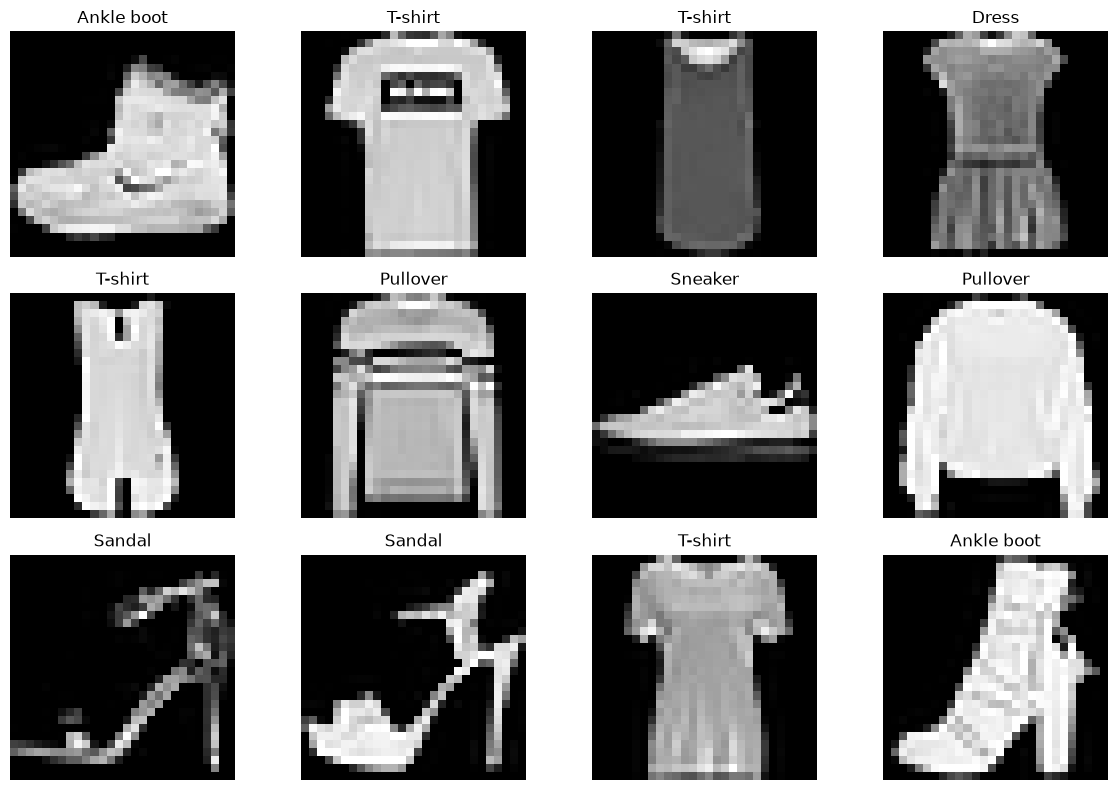

In [6]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(class_names[y_train[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

## Discusión
Preguntas
- ¿Qué dificultades presenta el dataset?
- ¿Qué clases parecen similares?

# Sección 5 — Preprocesamiento
## Normalización

In [7]:
X_train = X_train / 255.0

X_test = X_test / 255.0

## Agregar canal

CNN espera:

(batch, height, width, channels)

In [8]:
X_train = X_train.reshape(
    -1,28,28,1
)

X_test = X_test.reshape(
    -1,28,28,1
)

print(X_train.shape)

(60000, 28, 28, 1)


# Sección 6 — Primera CNN
## Arquitectura básica

In [9]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

## Resumen del modelo

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Interpretación
Preguntas
- ¿Qué hace cada convolución?
- ¿Qué hace el pooling?
- ¿Por qué usamos softmax?

# Sección 7 — Compilación
## Softmax

$P(y=i)= \frac{e^{z_i}}{\Sigma_j{e^{z_j}}} $

## Compilar


In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Sección 8 — Entrenamiento
## Early Stopping

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Entrenamiento

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8135 - loss: 0.5142 - val_accuracy: 0.8678 - val_loss: 0.3749
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8761 - loss: 0.3457 - val_accuracy: 0.8845 - val_loss: 0.3243
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8926 - loss: 0.2967 - val_accuracy: 0.8916 - val_loss: 0.3071
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9031 - loss: 0.2637 - val_accuracy: 0.8948 - val_loss: 0.3026
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9124 - loss: 0.2369 - val_accuracy: 0.8958 - val_loss: 0.2933
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9215 - loss: 0.2130 - val_accuracy: 0.8997 - val_loss: 0.2894
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9289 - loss: 0.1933 - val_accuracy: 0.9034 - val_loss: 0.2840
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9379 - loss: 0.1741 - v

# Sección 9 — Evaluación
## Evaluación final

In [14]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss:", loss)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9015 - loss: 0.2917
Loss: 0.2916639447212219
Accuracy: 0.9014999866485596


## Predicciones

In [15]:
y_prob = model.predict(X_test)

y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## Classification Report

In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.90      0.78      0.84      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.81      0.90      0.85      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.88      0.81      0.84      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.69      0.79      0.74      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



## Matriz de confusión

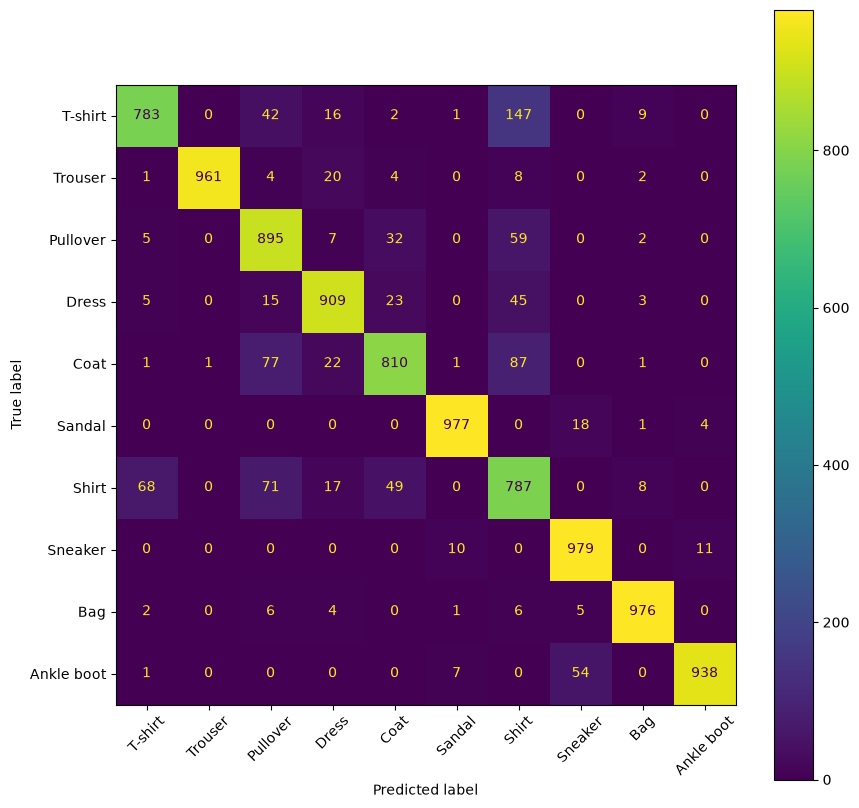

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax)

plt.xticks(rotation=45)

plt.show()

# Sección 10 — Visualización del Aprendizaje
## Accuracy

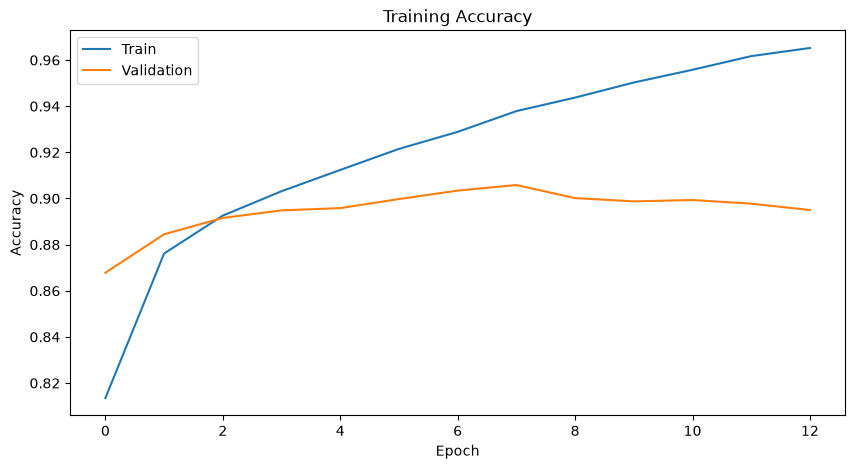

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.show()

## Loss

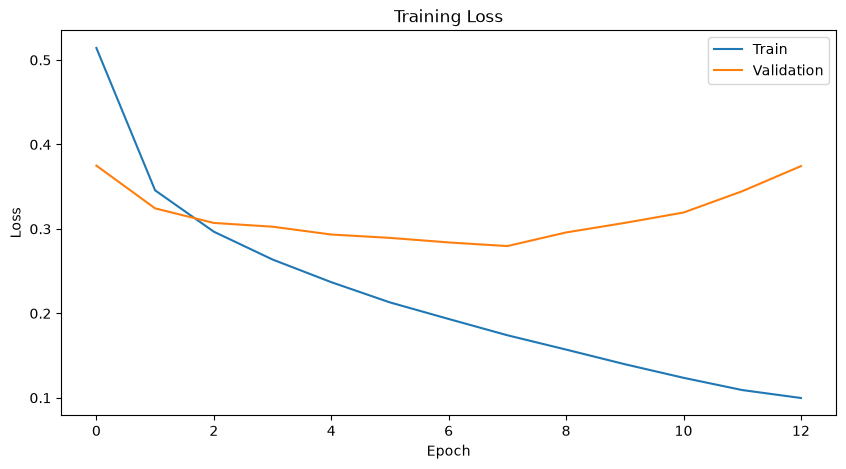

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

## Interpretación
Preguntas
- ¿Existe overfitting?
- ¿La red converge correctamente?

# Sección 11 — Data Augmentation
## ¿Por qué augmentation?

Genera nuevas imágenes artificiales:

- rotaciones,
- zoom,
- desplazamientos.

Ayuda a generalizar.

In [20]:
datagen = ImageDataGenerator(

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1
)

datagen.fit(X_train)

## Visualizar imágenes aumentadas

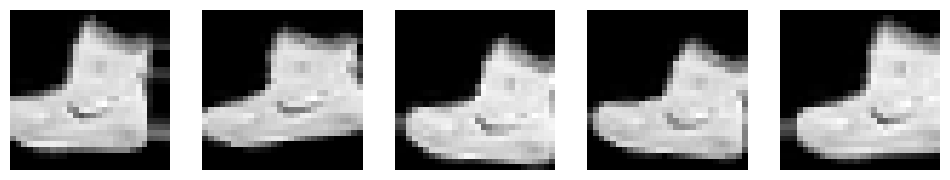

In [21]:
sample = X_train[:1]

plt.figure(figsize=(12,4))

i = 0

for batch in datagen.flow(sample, batch_size=1):

    plt.subplot(1,5,i+1)

    plt.imshow(
        batch[0].reshape(28,28),
        cmap="gray"
    )

    plt.axis("off")

    i += 1

    if i == 5:
        break

plt.show()

# Sección 12 — CNN con Dropout
## Modelo regularizado

In [22]:
dropout_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )
])

## Compilar

In [23]:
dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Entrenar

In [24]:
history_dropout = dropout_model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30


I0000 00:00:1782501995.770009  267409 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.6821 - loss: 0.8549 - val_accuracy: 0.7907 - val_loss: 0.5226
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7633 - loss: 0.6280 - val_accuracy: 0.8307 - val_loss: 0.4390
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.7900 - loss: 0.5644 - val_accuracy: 0.8446 - val_loss: 0.4207
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8036 - loss: 0.5236 - val_accuracy: 0.8428 - val_loss: 0.4059
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8173 - loss: 0.4926 - val_accuracy: 0.8715 - val_loss: 0.3522


## Comparación

In [25]:
loss1, acc1 = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

loss2, acc2 = dropout_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

comparison = {
    "CNN Básica": acc1,
    "CNN Regularizada": acc2
}

print(comparison)

{'CNN Básica': 0.9014999866485596, 'CNN Regularizada': 0.7907000184059143}


# Sección 13 — Introducción a Transfer Learning
## Concepto

Transfer Learning:

- reutiliza redes preentrenadas,
- acelera entrenamiento,
- mejora precisión.

## Modelos comunes
- VGG16
- ResNet
- EfficientNet
- MobileNet

## Ejemplo conceptual

In [26]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False
)

print(base_model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_layer_2[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


## Discusión
Preguntas
- ¿Por qué funciona transfer learning?
- ¿Qué ventajas posee?

# Sección 14 — Predicciones Individuales

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


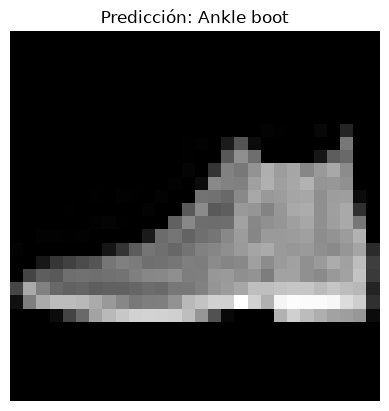

In [27]:
index = 0

sample = X_test[index]

prediction = model.predict(
    sample.reshape(1,28,28,1)
)

predicted_class = np.argmax(prediction)

plt.imshow(
    sample.reshape(28,28),
    cmap="gray"
)

plt.title(
    f"Predicción: {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()

# Sección 15 — Interpretabilidad Visual
## Ideas importantes

Las CNN aprenden:

- bordes,
- texturas,
- patrones complejos,
- estructuras jerárquicas.

## Limitaciones
- baja interpretabilidad,
- alta demanda computacional,
- necesidad de muchos datos.